<a href="https://colab.research.google.com/github/HeshanNavindu-7/Trajectory-prediction/blob/main/06_lstm_trajectory_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# Step 1: Setup Drive, Folders, and Paths
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os
import json
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Main project path
OIL_SPILL_ROOT = Path("/content/drive/MyDrive/Oil Spill")
TRAJECTORY_DIR = OIL_SPILL_ROOT / "04_Trajectory_LSTM"

DATA_DIR = TRAJECTORY_DIR / "data"
GENERATED_DIR = DATA_DIR / "generated"
SPLITS_DIR = DATA_DIR / "splits"
SEQUENCES_DIR = DATA_DIR / "sequences"

SCALER_DIR = TRAJECTORY_DIR / "scalers"
MODEL_DIR = TRAJECTORY_DIR / "models"
RESULT_DIR = TRAJECTORY_DIR / "results"
PLOT_DIR = TRAJECTORY_DIR / "plots"
LOG_DIR = TRAJECTORY_DIR / "logs"

for folder in [
    SEQUENCES_DIR,
    SCALER_DIR,
    MODEL_DIR,
    RESULT_DIR,
    PLOT_DIR,
    LOG_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

# Input files
TRAJECTORY_DATASET_PATH = GENERATED_DIR / "lados_initialized_physics_trajectory_dataset.csv"
TRAIN_IDS_PATH = SPLITS_DIR / "train_spill_ids.csv"
VALID_IDS_PATH = SPLITS_DIR / "valid_spill_ids.csv"
TEST_IDS_PATH = SPLITS_DIR / "test_spill_ids.csv"

# Output files
X_SCALER_PATH = SCALER_DIR / "trajectory_feature_scaler_X.pkl"
Y_SCALER_PATH = SCALER_DIR / "trajectory_target_scaler_y.pkl"

TRAIN_SEQ_PATH = SEQUENCES_DIR / "lstm_train_sequences.npz"
VALID_SEQ_PATH = SEQUENCES_DIR / "lstm_valid_sequences.npz"
TEST_SEQ_PATH = SEQUENCES_DIR / "lstm_test_sequences.npz"

TRAIN_META_PATH = SEQUENCES_DIR / "lstm_train_sequence_metadata.csv"
VALID_META_PATH = SEQUENCES_DIR / "lstm_valid_sequence_metadata.csv"
TEST_META_PATH = SEQUENCES_DIR / "lstm_test_sequence_metadata.csv"

BEST_MODEL_PATH = MODEL_DIR / "best_lstm_trajectory_model.keras"
TRAINING_LOG_PATH = LOG_DIR / "lstm_training_log.csv"

print("Trajectory dataset exists:", TRAJECTORY_DATASET_PATH.exists())
print("Train IDs exists:", TRAIN_IDS_PATH.exists())
print("Valid IDs exists:", VALID_IDS_PATH.exists())
print("Test IDs exists:", TEST_IDS_PATH.exists())

Mounted at /content/drive
Trajectory dataset exists: True
Train IDs exists: True
Valid IDs exists: True
Test IDs exists: True


In [4]:
# ============================================================
# Step 2: Load Trajectory Dataset
# ============================================================

trajectory_df = pd.read_csv(TRAJECTORY_DATASET_PATH)

trajectory_df = trajectory_df.sort_values(
    ["spill_id", "time_hour"]
).reset_index(drop=True)

print("Trajectory dataset shape:", trajectory_df.shape)
print("Unique spill events:", trajectory_df["spill_id"].nunique())
print("Missing values:", int(trajectory_df.isnull().sum().sum()))

print("\nRows per event:")
print(trajectory_df.groupby("spill_id")["time_hour"].count().describe())

print("\nMetocean source:")
print(trajectory_df["metocean_source"].value_counts())

trajectory_df.head()

Trajectory dataset shape: (26925, 28)
Unique spill events: 1795
Missing values: 0

Rows per event:
count    1795.0
mean       15.0
std         0.0
min        15.0
25%        15.0
50%        15.0
75%        15.0
max        15.0
Name: time_hour, dtype: float64

Metocean source:
metocean_source
physics_guided_simulation    26925
Name: count, dtype: int64


,spill_id,source_image_id,source_split,time_hour,x_m,y_m,area_pixels,area_ratio,bbox_width,bbox_height,...,drift_v,delta_x_m,delta_y_m,spatial_step_m,target_x_m,target_y_m,next_area_pixels,next_area_ratio,area_growth_rate,metocean_source
0,SPILL_00000,01_taylor_jpeg_jpg.rf.4a466016aec4913557fe9fe8...,train,0,918.816172,1206.511402,310131.000000,0.757156,638.0,613.0,...,-0.258126,218.710922,-1029.384851,1052.362884,1137.527094,177.126550,311869.622559,0.761400,0.005606,physics_guided_simulation
1,SPILL_00000,01_taylor_jpeg_jpg.rf.4a466016aec4913557fe9fe8...,train,1,1137.527094,177.126550,311869.622559,0.761400,638.0,613.0,...,-0.208571,190.763100,-816.134848,838.132836,1328.290194,-639.008298,316875.892166,0.773623,0.016052,physics_guided_simulation
2,SPILL_00000,01_taylor_jpeg_jpg.rf.4a466016aec4913557fe9fe8...,train,2,1328.290194,-639.008298,316875.892166,0.773623,638.0,613.0,...,-0.153581,285.132456,-601.709698,665.849141,1613.422650,-1240.717996,319716.419657,0.780558,0.008964,physics_guided_simulation
3,SPILL_00000,01_taylor_jpeg_jpg.rf.4a466016aec4913557fe9fe8...,train,3,1613.422650,-1240.717996,319716.419657,0.780558,638.0,613.0,...,-0.090881,239.480147,-361.978562,434.026750,1852.902797,-1602.696557,321898.347679,0.785885,0.006825,physics_guided_simulation
4,SPILL_00000,01_taylor_jpeg_jpg.rf.4a466016aec4913557fe9fe8...,train,4,1852.902797,-1602.696557,321898.347679,0.785885,638.0,613.0,...,-0.093315,137.962307,-366.498055,391.604932,1990.865104,-1969.194612,325046.352886,0.793570,0.009780,physics_guided_simulation


In [5]:
# ============================================================
# Step 3: Load Train / Valid / Test Spill IDs
# ============================================================

train_ids = pd.read_csv(TRAIN_IDS_PATH)["spill_id"].tolist()
valid_ids = pd.read_csv(VALID_IDS_PATH)["spill_id"].tolist()
test_ids = pd.read_csv(TEST_IDS_PATH)["spill_id"].tolist()

train_df = trajectory_df[trajectory_df["spill_id"].isin(train_ids)].copy()
valid_df = trajectory_df[trajectory_df["spill_id"].isin(valid_ids)].copy()
test_df = trajectory_df[trajectory_df["spill_id"].isin(test_ids)].copy()

train_df = train_df.sort_values(["spill_id", "time_hour"]).reset_index(drop=True)
valid_df = valid_df.sort_values(["spill_id", "time_hour"]).reset_index(drop=True)
test_df = test_df.sort_values(["spill_id", "time_hour"]).reset_index(drop=True)

print("Train events:", train_df["spill_id"].nunique(), "Rows:", len(train_df))
print("Valid events:", valid_df["spill_id"].nunique(), "Rows:", len(valid_df))
print("Test events :", test_df["spill_id"].nunique(), "Rows:", len(test_df))

# Leakage check
train_set = set(train_ids)
valid_set = set(valid_ids)
test_set = set(test_ids)

print("\nLeakage check:")
print("Train ∩ Valid:", len(train_set.intersection(valid_set)))
print("Train ∩ Test :", len(train_set.intersection(test_set)))
print("Valid ∩ Test :", len(valid_set.intersection(test_set)))

Train events: 1235 Rows: 18525
Valid events: 370 Rows: 5550
Test events : 190 Rows: 2850

Leakage check:
Train ∩ Valid: 0
Train ∩ Test : 0
Valid ∩ Test : 0


In [6]:
# ============================================================
# Step 4: Define LSTM Features and Target
# ============================================================

FEATURE_COLS = [
    "x_m",
    "y_m",
    "area_pixels",
    "area_ratio",
    "bbox_width",
    "bbox_height",
    "slick_type_id",
    "wind_u",
    "wind_v",
    "current_u",
    "current_v",
    "wave_height"
]

TARGET_COLS = [
    "delta_x_m",
    "delta_y_m"
]

SEQUENCE_LENGTH = 3

required_cols = FEATURE_COLS + TARGET_COLS + [
    "spill_id",
    "time_hour",
    "target_x_m",
    "target_y_m",
    "spatial_step_m"
]

missing_cols = [col for col in required_cols if col not in trajectory_df.columns]

if len(missing_cols) > 0:
    raise ValueError(f"Missing columns: {missing_cols}")

print("Feature columns:", FEATURE_COLS)
print("Target columns:", TARGET_COLS)
print("Sequence length:", SEQUENCE_LENGTH)
print("Number of features:", len(FEATURE_COLS))

Feature columns: ['x_m', 'y_m', 'area_pixels', 'area_ratio', 'bbox_width', 'bbox_height', 'slick_type_id', 'wind_u', 'wind_v', 'current_u', 'current_v', 'wave_height']
Target columns: ['delta_x_m', 'delta_y_m']
Sequence length: 3
Number of features: 12


In [7]:
# ============================================================
# Step 5: Fit Scalers Only on Training Data
# ============================================================

x_scaler = StandardScaler()
y_scaler = StandardScaler()

x_scaler.fit(train_df[FEATURE_COLS])
y_scaler.fit(train_df[TARGET_COLS])

joblib.dump(x_scaler, X_SCALER_PATH)
joblib.dump(y_scaler, Y_SCALER_PATH)

print("Saved X scaler:", X_SCALER_PATH)
print("Saved y scaler:", Y_SCALER_PATH)

def apply_scalers(df):
    scaled_df = df.copy()
    scaled_df[FEATURE_COLS] = x_scaler.transform(df[FEATURE_COLS])
    scaled_df[TARGET_COLS] = y_scaler.transform(df[TARGET_COLS])
    return scaled_df

train_scaled_df = apply_scalers(train_df)
valid_scaled_df = apply_scalers(valid_df)
test_scaled_df = apply_scalers(test_df)

print("Scaling completed.")

Saved X scaler: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/scalers/trajectory_feature_scaler_X.pkl
Saved y scaler: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/scalers/trajectory_target_scaler_y.pkl
Scaling completed.


In [8]:
# ============================================================
# Step 6: Create LSTM Sequences
# ============================================================

def create_lstm_sequences(raw_df, scaled_df, sequence_length):
    X_list = []
    y_list = []
    meta_rows = []

    grouped_raw = raw_df.groupby("spill_id")
    grouped_scaled = scaled_df.groupby("spill_id")

    for spill_id, raw_event_df in grouped_raw:
        raw_event_df = raw_event_df.sort_values("time_hour").reset_index(drop=True)
        scaled_event_df = grouped_scaled.get_group(spill_id).sort_values("time_hour").reset_index(drop=True)

        if len(raw_event_df) <= sequence_length:
            continue

        for idx in range(sequence_length, len(raw_event_df)):
            X_seq = scaled_event_df.iloc[idx-sequence_length:idx][FEATURE_COLS].values
            y_target = scaled_event_df.iloc[idx][TARGET_COLS].values

            target_row = raw_event_df.iloc[idx]
            previous_row = raw_event_df.iloc[idx - 1]

            X_list.append(X_seq)
            y_list.append(y_target)

            meta_rows.append({
                "spill_id": spill_id,
                "source_split": target_row["source_split"],
                "source_image_id": target_row["source_image_id"],
                "time_hour": int(target_row["time_hour"]),

                "x_m": float(target_row["x_m"]),
                "y_m": float(target_row["y_m"]),

                "actual_delta_x_m": float(target_row["delta_x_m"]),
                "actual_delta_y_m": float(target_row["delta_y_m"]),
                "actual_target_x_m": float(target_row["target_x_m"]),
                "actual_target_y_m": float(target_row["target_y_m"]),

                "prev_delta_x_m": float(previous_row["delta_x_m"]),
                "prev_delta_y_m": float(previous_row["delta_y_m"]),

                "prev_wind_u": float(previous_row["wind_u"]),
                "prev_wind_v": float(previous_row["wind_v"]),
                "prev_current_u": float(previous_row["current_u"]),
                "prev_current_v": float(previous_row["current_v"]),
                "prev_wave_height": float(previous_row["wave_height"])
            })

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    meta_df = pd.DataFrame(meta_rows)

    return X, y, meta_df


X_train, y_train, meta_train = create_lstm_sequences(
    train_df,
    train_scaled_df,
    SEQUENCE_LENGTH
)

X_valid, y_valid, meta_valid = create_lstm_sequences(
    valid_df,
    valid_scaled_df,
    SEQUENCE_LENGTH
)

X_test, y_test, meta_test = create_lstm_sequences(
    test_df,
    test_scaled_df,
    SEQUENCE_LENGTH
)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_valid:", X_valid.shape, "y_valid:", y_valid.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

meta_train.head()

X_train: (14820, 3, 12) y_train: (14820, 2)
X_valid: (4440, 3, 12) y_valid: (4440, 2)
X_test : (2280, 3, 12) y_test : (2280, 2)


,spill_id,source_split,source_image_id,time_hour,x_m,y_m,actual_delta_x_m,actual_delta_y_m,actual_target_x_m,actual_target_y_m,prev_delta_x_m,prev_delta_y_m,prev_wind_u,prev_wind_v,prev_current_u,prev_current_v,prev_wave_height
0,SPILL_00000,train,01_taylor_jpeg_jpg.rf.4a466016aec4913557fe9fe8...,3,1613.422650,-1240.717996,239.480147,-361.978562,1852.902797,-1602.696557,285.132456,-601.709698,-0.587315,-1.223229,0.090316,-0.116884,3.035261
1,SPILL_00000,train,01_taylor_jpeg_jpg.rf.4a466016aec4913557fe9fe8...,4,1852.902797,-1602.696557,137.962307,-366.498055,1990.865104,-1969.194612,239.480147,-361.978562,-0.706068,0.323543,0.080677,-0.100587,3.127295
2,SPILL_00000,train,01_taylor_jpeg_jpg.rf.4a466016aec4913557fe9fe8...,5,1990.865104,-1969.194612,213.053703,-418.221721,2203.918807,-2387.416334,137.962307,-366.498055,-0.848837,-0.265515,0.058157,-0.085350,2.767626
3,SPILL_00000,train,01_taylor_jpeg_jpg.rf.4a466016aec4913557fe9fe8...,6,2203.918807,-2387.416334,210.916843,-311.957440,2414.835651,-2699.373774,213.053703,-418.221721,0.008117,-0.756534,0.057163,-0.083344,2.913428
4,SPILL_00000,train,01_taylor_jpeg_jpg.rf.4a466016aec4913557fe9fe8...,7,2414.835651,-2699.373774,294.825690,-174.156429,2709.661340,-2873.530202,210.916843,-311.957440,0.147895,0.062563,0.050140,-0.079999,2.441058


In [9]:
# ============================================================
# Step 7: Save LSTM Sequence Files
# ============================================================

np.savez(
    TRAIN_SEQ_PATH,
    X=X_train,
    y=y_train
)

np.savez(
    VALID_SEQ_PATH,
    X=X_valid,
    y=y_valid
)

np.savez(
    TEST_SEQ_PATH,
    X=X_test,
    y=y_test
)

meta_train.to_csv(TRAIN_META_PATH, index=False)
meta_valid.to_csv(VALID_META_PATH, index=False)
meta_test.to_csv(TEST_META_PATH, index=False)

print("Saved:", TRAIN_SEQ_PATH)
print("Saved:", VALID_SEQ_PATH)
print("Saved:", TEST_SEQ_PATH)

print("Saved:", TRAIN_META_PATH)
print("Saved:", VALID_META_PATH)
print("Saved:", TEST_META_PATH)

Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/sequences/lstm_train_sequences.npz
Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/sequences/lstm_valid_sequences.npz
Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/sequences/lstm_test_sequences.npz
Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/sequences/lstm_train_sequence_metadata.csv
Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/sequences/lstm_valid_sequence_metadata.csv
Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/sequences/lstm_test_sequence_metadata.csv


In [10]:
# ============================================================
# Step 8: Define Evaluation Function
# ============================================================

def calculate_trajectory_metrics(y_true_m, y_pred_m, model_name):
    true_dx = y_true_m[:, 0]
    true_dy = y_true_m[:, 1]

    pred_dx = y_pred_m[:, 0]
    pred_dy = y_pred_m[:, 1]

    error_x = true_dx - pred_dx
    error_y = true_dy - pred_dy

    spatial_error = np.sqrt(error_x**2 + error_y**2)

    metrics = {
        "model": model_name,

        "mae_x_m": float(mean_absolute_error(true_dx, pred_dx)),
        "mae_y_m": float(mean_absolute_error(true_dy, pred_dy)),

        "rmse_x_m": float(np.sqrt(mean_squared_error(true_dx, pred_dx))),
        "rmse_y_m": float(np.sqrt(mean_squared_error(true_dy, pred_dy))),

        "r2_x": float(r2_score(true_dx, pred_dx)),
        "r2_y": float(r2_score(true_dy, pred_dy)),

        "mean_spatial_error_m": float(spatial_error.mean()),
        "median_spatial_error_m": float(np.median(spatial_error)),
        "max_spatial_error_m": float(spatial_error.max())
    }

    return metrics, spatial_error


# Inverse transform true test target
y_test_true_m = y_scaler.inverse_transform(y_test)

print("Evaluation helper ready.")
print("True test target shape:", y_test_true_m.shape)

Evaluation helper ready.
True test target shape: (2280, 2)


In [11]:
# ============================================================
# Step 9: Persistence Baseline
# Previous movement is used as next movement prediction.
# ============================================================

persistence_pred_m = meta_test[
    ["prev_delta_x_m", "prev_delta_y_m"]
].values

persistence_metrics, persistence_spatial_error = calculate_trajectory_metrics(
    y_true_m=y_test_true_m,
    y_pred_m=persistence_pred_m,
    model_name="Persistence Baseline"
)

persistence_metrics_df = pd.DataFrame([persistence_metrics])

PERSISTENCE_METRICS_PATH = RESULT_DIR / "persistence_baseline_metrics.csv"
persistence_metrics_df.to_csv(PERSISTENCE_METRICS_PATH, index=False)

print("Saved:", PERSISTENCE_METRICS_PATH)
persistence_metrics_df

Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/results/persistence_baseline_metrics.csv


,model,mae_x_m,mae_y_m,rmse_x_m,rmse_y_m,r2_x,r2_y,mean_spatial_error_m,median_spatial_error_m,max_spatial_error_m
0,Persistence Baseline,80.611203,79.902631,100.196045,100.005703,0.778241,0.784747,125.694682,119.122019,392.618106


In [12]:
# ============================================================
# Step 10: Physics Baseline
# Uses previous metocean state to estimate next movement.
# ============================================================

HOUR_SECONDS = 3600
WIND_DRIFT_FACTOR = 0.03

prev_wind_u = meta_test["prev_wind_u"].values
prev_wind_v = meta_test["prev_wind_v"].values
prev_current_u = meta_test["prev_current_u"].values
prev_current_v = meta_test["prev_current_v"].values
prev_wave_height = meta_test["prev_wave_height"].values

wave_factor = 1.0 + (0.03 * prev_wave_height)

physics_pred_dx = (prev_current_u + WIND_DRIFT_FACTOR * prev_wind_u) * HOUR_SECONDS * wave_factor
physics_pred_dy = (prev_current_v + WIND_DRIFT_FACTOR * prev_wind_v) * HOUR_SECONDS * wave_factor

physics_pred_m = np.column_stack([physics_pred_dx, physics_pred_dy])

physics_metrics, physics_spatial_error = calculate_trajectory_metrics(
    y_true_m=y_test_true_m,
    y_pred_m=physics_pred_m,
    model_name="Physics Baseline"
)

physics_metrics_df = pd.DataFrame([physics_metrics])

PHYSICS_METRICS_PATH = RESULT_DIR / "physics_baseline_metrics.csv"
physics_metrics_df.to_csv(PHYSICS_METRICS_PATH, index=False)

print("Saved:", PHYSICS_METRICS_PATH)
physics_metrics_df

Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/results/physics_baseline_metrics.csv


,model,mae_x_m,mae_y_m,rmse_x_m,rmse_y_m,r2_x,r2_y,mean_spatial_error_m,median_spatial_error_m,max_spatial_error_m
0,Physics Baseline,80.553251,79.640033,99.928236,99.616047,0.779425,0.786421,125.460037,118.298011,390.045519


In [13]:
# ============================================================
# Step 11: Build LSTM Trajectory Prediction Model
# ============================================================

num_features = X_train.shape[2]

model = Sequential([
    Input(shape=(SEQUENCE_LENGTH, num_features)),

    LSTM(64, return_sequences=True),
    Dropout(0.20),

    LSTM(32, return_sequences=False),
    Dropout(0.20),

    Dense(32, activation="relu"),
    Dropout(0.10),

    Dense(2, activation="linear")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 3, 64)          │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,250 (129.88 KB)

 Trainable params: 33,250 (129.88 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# ============================================================
# Step 12: Train LSTM Model
# ============================================================

callbacks = [
    ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=6,
        min_lr=1e-6,
        verbose=1
    ),
    CSVLogger(
        filename=TRAINING_LOG_PATH,
        append=False
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

print("Training complete.")
print("Best model saved:", BEST_MODEL_PATH)
print("Training log saved:", TRAINING_LOG_PATH)

Epoch 1/100
230/232 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3897 - mae: 0.4790
Epoch 1: val_loss improved from None to 0.18134, saving model to /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/models/best_lstm_trajectory_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/models/best_lstm_trajectory_model.keras
232/232 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.2765 - mae: 0.4083 - val_loss: 0.1813 - val_mae: 0.3408 - learning_rate: 0.0010
Epoch 2/100
228/232 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1926 - mae: 0.3503
Epoch 2: val_loss improved from 0.18134 to 0.14504, saving model to /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/models/best_lstm_trajectory_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/models/best_lstm_trajectory_model.keras
232/232 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1838 - mae: 0.3417 - val_loss: 0.1450 - val_mae: 0.3047 - learning_rate: 0.0010
Ep

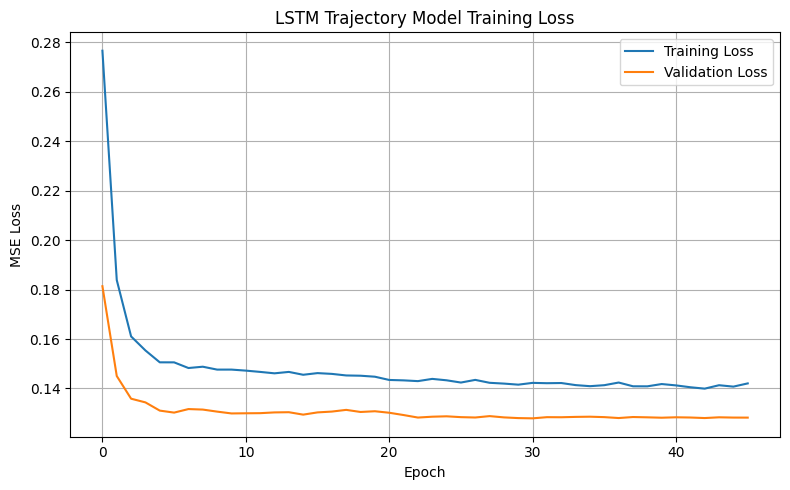

Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/plots/lstm_training_loss_curve.png


In [15]:
# ============================================================
# Step 13: Plot Training Loss Curve
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Trajectory Model Training Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

TRAINING_LOSS_PLOT_PATH = PLOT_DIR / "lstm_training_loss_curve.png"
plt.savefig(TRAINING_LOSS_PLOT_PATH, dpi=200)
plt.show()

print("Saved:", TRAINING_LOSS_PLOT_PATH)

In [16]:
# ============================================================
# Step 14: Evaluate LSTM on Test Set
# ============================================================

best_model = tf.keras.models.load_model(BEST_MODEL_PATH)

y_test_pred_scaled = best_model.predict(X_test)

y_test_pred_m = y_scaler.inverse_transform(y_test_pred_scaled)
y_test_true_m = y_scaler.inverse_transform(y_test)

lstm_metrics, lstm_spatial_error = calculate_trajectory_metrics(
    y_true_m=y_test_true_m,
    y_pred_m=y_test_pred_m,
    model_name="LSTM Model"
)

lstm_metrics_df = pd.DataFrame([lstm_metrics])

LSTM_METRICS_PATH = RESULT_DIR / "lstm_trajectory_metrics.csv"
lstm_metrics_df.to_csv(LSTM_METRICS_PATH, index=False)

print("Saved:", LSTM_METRICS_PATH)
lstm_metrics_df

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/results/lstm_trajectory_metrics.csv


,model,mae_x_m,mae_y_m,rmse_x_m,rmse_y_m,r2_x,r2_y,mean_spatial_error_m,median_spatial_error_m,max_spatial_error_m
0,LSTM Model,74.212845,71.781593,92.518532,90.174232,0.810923,0.824989,114.705994,107.696365,318.899139


In [17]:
# ============================================================
# Step 15: Save LSTM Test Predictions
# ============================================================

predictions_df = meta_test.copy()

predictions_df["actual_delta_x_m"] = y_test_true_m[:, 0]
predictions_df["actual_delta_y_m"] = y_test_true_m[:, 1]

predictions_df["pred_delta_x_m"] = y_test_pred_m[:, 0]
predictions_df["pred_delta_y_m"] = y_test_pred_m[:, 1]

predictions_df["pred_target_x_m"] = predictions_df["x_m"] + predictions_df["pred_delta_x_m"]
predictions_df["pred_target_y_m"] = predictions_df["y_m"] + predictions_df["pred_delta_y_m"]

predictions_df["error_x_m"] = predictions_df["actual_delta_x_m"] - predictions_df["pred_delta_x_m"]
predictions_df["error_y_m"] = predictions_df["actual_delta_y_m"] - predictions_df["pred_delta_y_m"]

predictions_df["spatial_error_m"] = np.sqrt(
    predictions_df["error_x_m"]**2 + predictions_df["error_y_m"]**2
)

LSTM_TEST_PREDICTIONS_PATH = RESULT_DIR / "lstm_test_predictions.csv"
predictions_df.to_csv(LSTM_TEST_PREDICTIONS_PATH, index=False)

print("Saved:", LSTM_TEST_PREDICTIONS_PATH)
predictions_df.head()

Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/results/lstm_test_predictions.csv


,spill_id,source_split,source_image_id,time_hour,x_m,y_m,actual_delta_x_m,actual_delta_y_m,actual_target_x_m,actual_target_y_m,...,prev_current_u,prev_current_v,prev_wave_height,pred_delta_x_m,pred_delta_y_m,pred_target_x_m,pred_target_y_m,error_x_m,error_y_m,spatial_error_m
0,SPILL_01605,test,05_73_jpg.rf.f0da9f29ff04c086fe8a1fd9de6e8c8e,3,1394.893231,-250.304726,72.130981,-78.166611,1467.024221,-328.471340,...,0.036859,-0.048279,1.451671,103.038727,-166.207367,1497.931958,-416.512093,-30.907745,88.040756,93.308434
1,SPILL_01605,test,05_73_jpg.rf.f0da9f29ff04c086fe8a1fd9de6e8c8e,4,1467.024221,-328.471340,-43.710140,5.854803,1423.314080,-322.616537,...,0.022127,-0.045911,1.841406,67.985489,-90.184525,1535.009710,-418.655864,-111.695633,96.039330,147.307388
2,SPILL_01605,test,05_73_jpg.rf.f0da9f29ff04c086fe8a1fd9de6e8c8e,5,1423.314080,-322.616537,-106.845840,-18.752319,1316.468246,-341.368856,...,0.013223,-0.049171,2.070985,-47.818138,-27.013374,1375.495942,-349.629911,-59.027702,8.261055,59.602974
3,SPILL_01605,test,05_73_jpg.rf.f0da9f29ff04c086fe8a1fd9de6e8c8e,6,1316.468246,-341.368856,24.061396,-131.473923,1340.529641,-472.842774,...,0.005332,-0.046687,2.353189,-81.160431,-43.942612,1235.307815,-385.311467,105.221825,-87.531311,136.869873
4,SPILL_01605,test,05_73_jpg.rf.f0da9f29ff04c086fe8a1fd9de6e8c8e,7,1340.529641,-472.842774,-25.108440,-8.157444,1315.421199,-481.000218,...,-0.001603,-0.048179,2.073663,17.870951,-127.574051,1358.400591,-600.416825,-42.979393,119.416611,126.915543


In [18]:
# ============================================================
# Step 16: Compare Baselines and LSTM
# ============================================================

comparison_df = pd.concat(
    [
        persistence_metrics_df,
        physics_metrics_df,
        lstm_metrics_df
    ],
    ignore_index=True
)

COMPARISON_PATH = RESULT_DIR / "lstm_model_comparison_metrics.csv"
comparison_df.to_csv(COMPARISON_PATH, index=False)

print("Saved:", COMPARISON_PATH)
comparison_df

Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/results/lstm_model_comparison_metrics.csv


,model,mae_x_m,mae_y_m,rmse_x_m,rmse_y_m,r2_x,r2_y,mean_spatial_error_m,median_spatial_error_m,max_spatial_error_m
0,Persistence Baseline,80.611203,79.902631,100.196045,100.005703,0.778241,0.784747,125.694682,119.122019,392.618106
1,Physics Baseline,80.553251,79.640033,99.928236,99.616047,0.779425,0.786421,125.460037,118.298011,390.045519
2,LSTM Model,74.212845,71.781593,92.518532,90.174232,0.810923,0.824989,114.705994,107.696365,318.899139


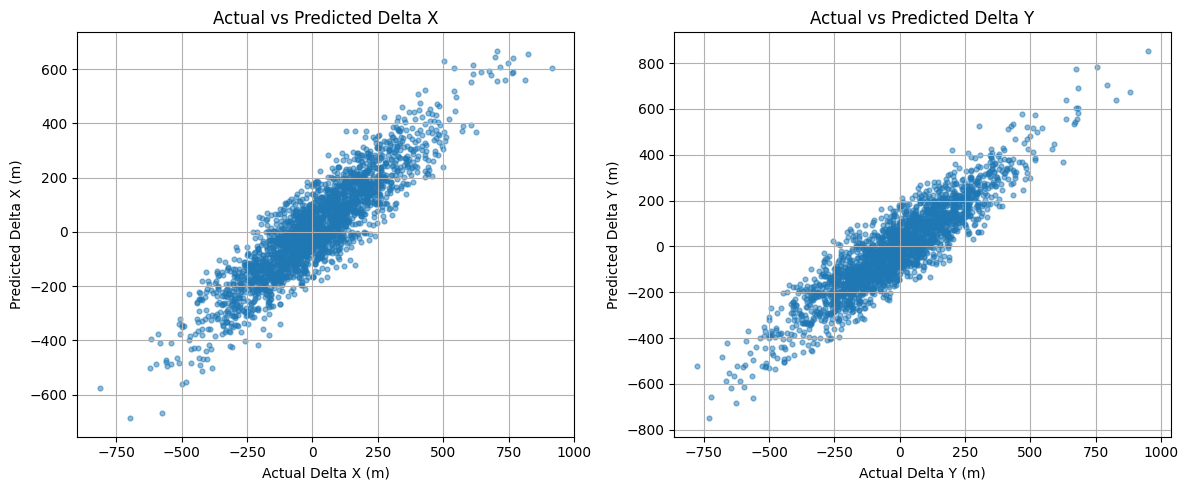

Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/plots/actual_vs_predicted_delta.png


In [19]:
# ============================================================
# Step 17: Plot Actual vs Predicted Delta
# ============================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(
    predictions_df["actual_delta_x_m"],
    predictions_df["pred_delta_x_m"],
    alpha=0.5,
    s=12
)
plt.xlabel("Actual Delta X (m)")
plt.ylabel("Predicted Delta X (m)")
plt.title("Actual vs Predicted Delta X")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(
    predictions_df["actual_delta_y_m"],
    predictions_df["pred_delta_y_m"],
    alpha=0.5,
    s=12
)
plt.xlabel("Actual Delta Y (m)")
plt.ylabel("Predicted Delta Y (m)")
plt.title("Actual vs Predicted Delta Y")
plt.grid(True)

plt.tight_layout()

ACTUAL_VS_PRED_DELTA_PATH = PLOT_DIR / "actual_vs_predicted_delta.png"
plt.savefig(ACTUAL_VS_PRED_DELTA_PATH, dpi=200)
plt.show()

print("Saved:", ACTUAL_VS_PRED_DELTA_PATH)

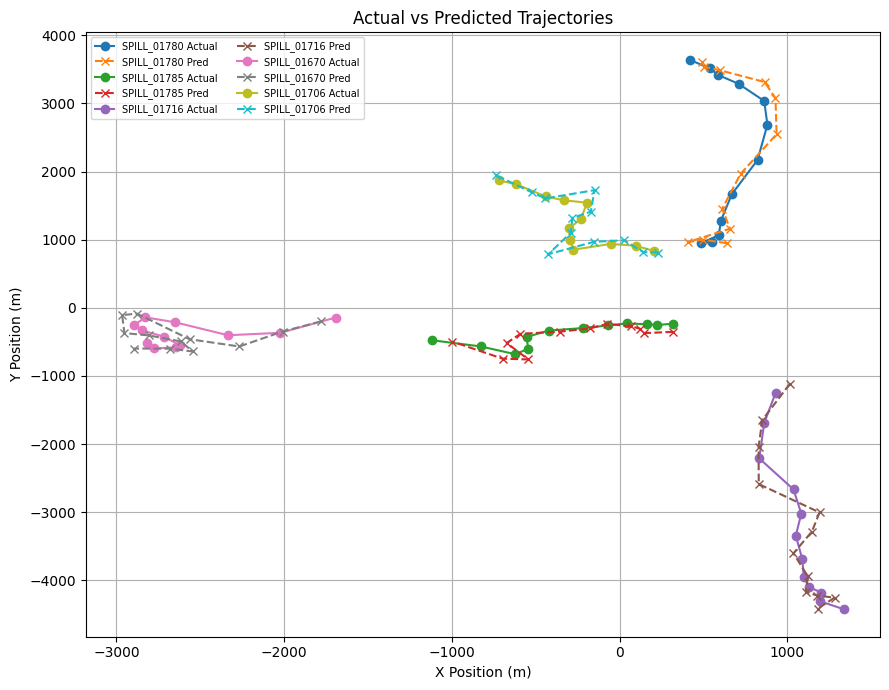

Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/plots/actual_vs_predicted_trajectory.png


In [20]:
# ============================================================
# Step 18: Plot Actual vs Predicted Trajectory
# ============================================================

sample_test_spill_ids = (
    predictions_df["spill_id"]
    .drop_duplicates()
    .sample(n=min(5, predictions_df["spill_id"].nunique()), random_state=42)
    .tolist()
)

plt.figure(figsize=(9, 7))

for spill_id in sample_test_spill_ids:
    sample_df = predictions_df[
        predictions_df["spill_id"] == spill_id
    ].sort_values("time_hour")

    plt.plot(
        sample_df["actual_target_x_m"],
        sample_df["actual_target_y_m"],
        marker="o",
        linewidth=1.5,
        label=f"{spill_id} Actual"
    )

    plt.plot(
        sample_df["pred_target_x_m"],
        sample_df["pred_target_y_m"],
        marker="x",
        linestyle="--",
        linewidth=1.5,
        label=f"{spill_id} Pred"
    )

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("Actual vs Predicted Trajectories")
plt.grid(True)
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()

ACTUAL_VS_PRED_TRAJ_PATH = PLOT_DIR / "actual_vs_predicted_trajectory.png"
plt.savefig(ACTUAL_VS_PRED_TRAJ_PATH, dpi=200)
plt.show()

print("Saved:", ACTUAL_VS_PRED_TRAJ_PATH)

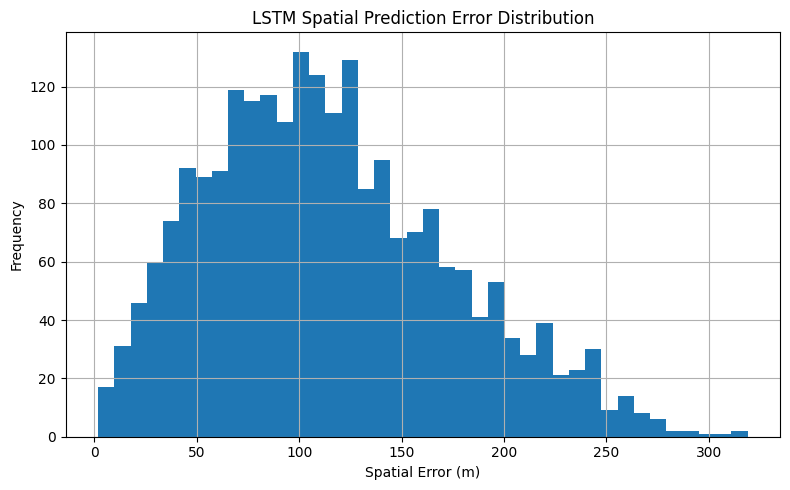

Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/plots/spatial_error_distribution.png


In [21]:
# ============================================================
# Step 19: Plot Spatial Error Distribution
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(predictions_df["spatial_error_m"], bins=40)

plt.xlabel("Spatial Error (m)")
plt.ylabel("Frequency")
plt.title("LSTM Spatial Prediction Error Distribution")
plt.grid(True)
plt.tight_layout()

SPATIAL_ERROR_PLOT_PATH = PLOT_DIR / "spatial_error_distribution.png"
plt.savefig(SPATIAL_ERROR_PLOT_PATH, dpi=200)
plt.show()

print("Saved:", SPATIAL_ERROR_PLOT_PATH)

In [22]:
# ============================================================
# Step 20: Save Final LSTM Trajectory Output Summary
# ============================================================

best_model_row = comparison_df.sort_values("mean_spatial_error_m").iloc[0]

summary_md = f"""
# LSTM Trajectory Model Training Summary

## Purpose
This notebook trains and evaluates an LSTM-based short-term oil spill trajectory prediction model using the LADOS-initialized physics-guided trajectory dataset.

## Input Dataset
`{TRAJECTORY_DATASET_PATH}`

## Dataset Summary
- Total trajectory rows: {len(trajectory_df)}
- Total spill events: {trajectory_df["spill_id"].nunique()}
- Train events: {len(train_ids)}
- Validation events: {len(valid_ids)}
- Test events: {len(test_ids)}
- Sequence length: {SEQUENCE_LENGTH}
- Input features: {len(FEATURE_COLS)}
- Target variables: delta_x_m, delta_y_m

## Input Features
{FEATURE_COLS}

## Target
{TARGET_COLS}

## Model
- Architecture: Stacked LSTM
- Loss function: Mean Squared Error
- Optimizer: Adam
- Output: 2D movement vector

## Baseline Models
1. Persistence Baseline
2. Physics Baseline

## LSTM Test Results
- MAE X: {lstm_metrics["mae_x_m"]:.4f} m
- MAE Y: {lstm_metrics["mae_y_m"]:.4f} m
- RMSE X: {lstm_metrics["rmse_x_m"]:.4f} m
- RMSE Y: {lstm_metrics["rmse_y_m"]:.4f} m
- R² X: {lstm_metrics["r2_x"]:.4f}
- R² Y: {lstm_metrics["r2_y"]:.4f}
- Mean Spatial Error: {lstm_metrics["mean_spatial_error_m"]:.4f} m
- Median Spatial Error: {lstm_metrics["median_spatial_error_m"]:.4f} m
- Max Spatial Error: {lstm_metrics["max_spatial_error_m"]:.4f} m

## Best Performing Model Based on Mean Spatial Error
- Model: {best_model_row["model"]}
- Mean Spatial Error: {best_model_row["mean_spatial_error_m"]:.4f} m

## Output Files
- Best LSTM model: `{BEST_MODEL_PATH}`
- Training log: `{TRAINING_LOG_PATH}`
- LSTM metrics: `{LSTM_METRICS_PATH}`
- Test predictions: `{LSTM_TEST_PREDICTIONS_PATH}`
- Model comparison: `{COMPARISON_PATH}`

## Plot Files
- `{TRAINING_LOSS_PLOT_PATH}`
- `{ACTUAL_VS_PRED_DELTA_PATH}`
- `{ACTUAL_VS_PRED_TRAJ_PATH}`
- `{SPATIAL_ERROR_PLOT_PATH}`

## Important Methodological Note
The LADOS dataset does not provide real synchronized temporal trajectory labels, GPS timestamps, or real metocean measurements. Therefore, the LSTM model was trained on a physics-guided simulated trajectory dataset initialized using LADOS-derived oil spill mask geometry. The results should be interpreted as controlled simulation-based trajectory forecasting performance rather than validation on real-world tracked oil spill trajectories.
"""

LSTM_SUMMARY_PATH = RESULT_DIR / "LSTM_TRAJECTORY_OUTPUT_SUMMARY.md"
LSTM_SUMMARY_PATH.write_text(summary_md)

print(summary_md)
print("Saved:", LSTM_SUMMARY_PATH)


# LSTM Trajectory Model Training Summary

## Purpose
This notebook trains and evaluates an LSTM-based short-term oil spill trajectory prediction model using the LADOS-initialized physics-guided trajectory dataset.

## Input Dataset
`/content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/generated/lados_initialized_physics_trajectory_dataset.csv`

## Dataset Summary
- Total trajectory rows: 26925
- Total spill events: 1795
- Train events: 1235
- Validation events: 370
- Test events: 190
- Sequence length: 3
- Input features: 12
- Target variables: delta_x_m, delta_y_m

## Input Features
['x_m', 'y_m', 'area_pixels', 'area_ratio', 'bbox_width', 'bbox_height', 'slick_type_id', 'wind_u', 'wind_v', 'current_u', 'current_v', 'wave_height']

## Target
['delta_x_m', 'delta_y_m']

## Model
- Architecture: Stacked LSTM
- Loss function: Mean Squared Error
- Optimizer: Adam
- Output: 2D movement vector

## Baseline Models
1. Persistence Baseline
2. Physics Baseline

## LSTM Test Results
- MAE X

In [23]:
# ============================================================
# Step 21: Final Output File Check
# ============================================================

required_files = [
    TRAIN_SEQ_PATH,
    VALID_SEQ_PATH,
    TEST_SEQ_PATH,

    X_SCALER_PATH,
    Y_SCALER_PATH,

    BEST_MODEL_PATH,
    TRAINING_LOG_PATH,

    PERSISTENCE_METRICS_PATH,
    PHYSICS_METRICS_PATH,
    LSTM_METRICS_PATH,
    COMPARISON_PATH,
    LSTM_TEST_PREDICTIONS_PATH,
    LSTM_SUMMARY_PATH,

    TRAINING_LOSS_PLOT_PATH,
    ACTUAL_VS_PRED_DELTA_PATH,
    ACTUAL_VS_PRED_TRAJ_PATH,
    SPATIAL_ERROR_PLOT_PATH
]

for file_path in required_files:
    print(file_path.name, "=>", file_path.exists())

lstm_train_sequences.npz => True
lstm_valid_sequences.npz => True
lstm_test_sequences.npz => True
trajectory_feature_scaler_X.pkl => True
trajectory_target_scaler_y.pkl => True
best_lstm_trajectory_model.keras => True
lstm_training_log.csv => True
persistence_baseline_metrics.csv => True
physics_baseline_metrics.csv => True
lstm_trajectory_metrics.csv => True
lstm_model_comparison_metrics.csv => True
lstm_test_predictions.csv => True
LSTM_TRAJECTORY_OUTPUT_SUMMARY.md => True
lstm_training_loss_curve.png => True
actual_vs_predicted_delta.png => True
actual_vs_predicted_trajectory.png => True
spatial_error_distribution.png => True


In [24]:
# ============================================================
# Step 22: Final Quick Result Display
# ============================================================

print("Notebook 06 completed.")
print("Best model path:", BEST_MODEL_PATH)
print("Test predictions:", LSTM_TEST_PREDICTIONS_PATH)
print("Comparison metrics:", COMPARISON_PATH)

comparison_df

Notebook 06 completed.
Best model path: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/models/best_lstm_trajectory_model.keras
Test predictions: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/results/lstm_test_predictions.csv
Comparison metrics: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/results/lstm_model_comparison_metrics.csv


,model,mae_x_m,mae_y_m,rmse_x_m,rmse_y_m,r2_x,r2_y,mean_spatial_error_m,median_spatial_error_m,max_spatial_error_m
0,Persistence Baseline,80.611203,79.902631,100.196045,100.005703,0.778241,0.784747,125.694682,119.122019,392.618106
1,Physics Baseline,80.553251,79.640033,99.928236,99.616047,0.779425,0.786421,125.460037,118.298011,390.045519
2,LSTM Model,74.212845,71.781593,92.518532,90.174232,0.810923,0.824989,114.705994,107.696365,318.899139
